<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES17Sim001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

# Global parameters
alpha = 0.2
beta = 0.001
steps = 50
num_seeds = 5


In [7]:
# --- Localized seed initializer ---
def initialize_with_seeds(D, N, seed=0):
    rng = np.random.default_rng(seed)
    s = np.zeros([N]*D)
    center = tuple([N//2]*D)
    s[center] = 1.0  # single spike
    s += 0.01 * rng.standard_normal([N]*D)  # small noise
    return s

# --- Laplacian evolution ---
def evolve_field(s, alpha=0.2, beta=0.001, steps=50, clip=10.0):
    for _ in range(steps):
        lap = np.zeros_like(s)
        for a in range(s.ndim):
            lap += np.roll(s, 1, axis=a) + np.roll(s, -1, axis=a) - 2*s
        s = s + alpha*lap - beta*(s**3)
        s = np.clip(s, -clip, clip)
        s -= s.mean()
    return s

# --- λ* estimator with DC masking ---
def measure_lambda_with_DC_masking(field, dx=1.0):
    F = np.fft.fftn(field)
    P = np.abs(F)**2
    P = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(2*np.pi*np.fft.fftfreq(n, d=dx)) for n in field.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    center = tuple(n//2 for n in P.shape)
    P[center] = 0.0  # mask DC
    peak = np.unravel_index(np.argmax(P), P.shape)
    k_mag = np.sqrt(sum(Ki[peak]**2 for Ki in K))
    return (2*np.pi/k_mag) if k_mag > 0 else np.inf


In [8]:
D_test = [3, 4, 5, 6]
results = {}

for D in D_test:
    N = 24 if D == 3 else (20 if D == 4 else (16 if D == 5 else 12))
    lam_ensemble = []
    for seed in range(num_seeds):
        s = initialize_with_seeds(D, N, seed=seed)
        s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
        lam = measure_lambda_with_DC_masking(s)
        lam_ensemble.append(lam)
    lam_array = np.array(lam_ensemble)
    results[D] = {
        'mean': lam_array.mean(),
        'std': lam_array.std(),
        'ci95': 1.96 * lam_array.std() / np.sqrt(num_seeds),
        'pred': 2/np.sqrt(D)
    }

for D in D_test:
    print(f"D={D}: λ* ≈ {results[D]['mean']:.3f} ± {results[D]['ci95']:.3f} (pred {results[D]['pred']:.3f})")


D=3: λ* ≈ 1.187 ± 0.019 (pred 1.155)
D=4: λ* ≈ 1.020 ± 0.009 (pred 1.000)
D=5: λ* ≈ 0.946 ± 0.024 (pred 0.894)
D=6: λ* ≈ 0.873 ± 0.023 (pred 0.816)


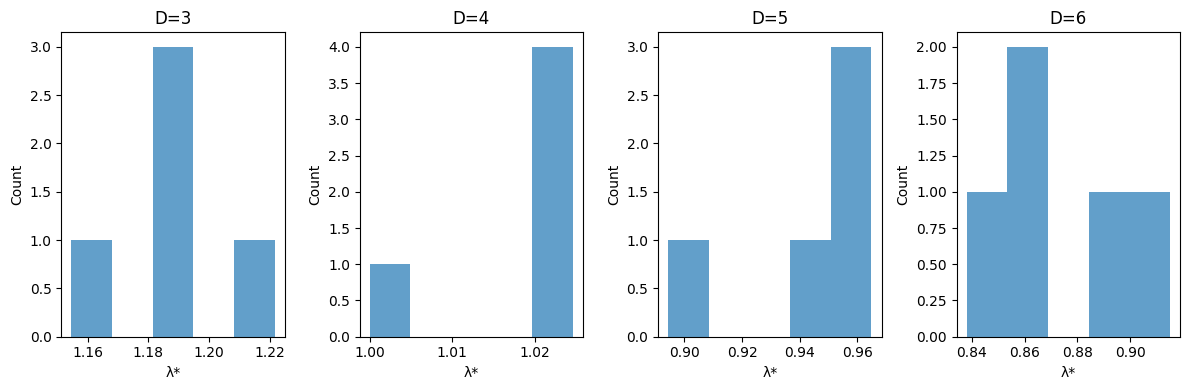

In [9]:
plt.figure(figsize=(12,4))
for i, D in enumerate(D_test):
    N = 24 if D == 3 else (20 if D == 4 else (16 if D == 5 else 12))
    lam_ensemble = []
    for seed in range(num_seeds):
        s = initialize_with_seeds(D, N, seed=seed)
        s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
        lam_ensemble.append(measure_lambda_with_DC_masking(s))
    plt.subplot(1, len(D_test), i+1)
    plt.hist(lam_ensemble, bins=5, alpha=0.7)
    plt.title(f"D={D}")
    plt.xlabel("λ*"); plt.ylabel("Count")
plt.tight_layout(); plt.show()


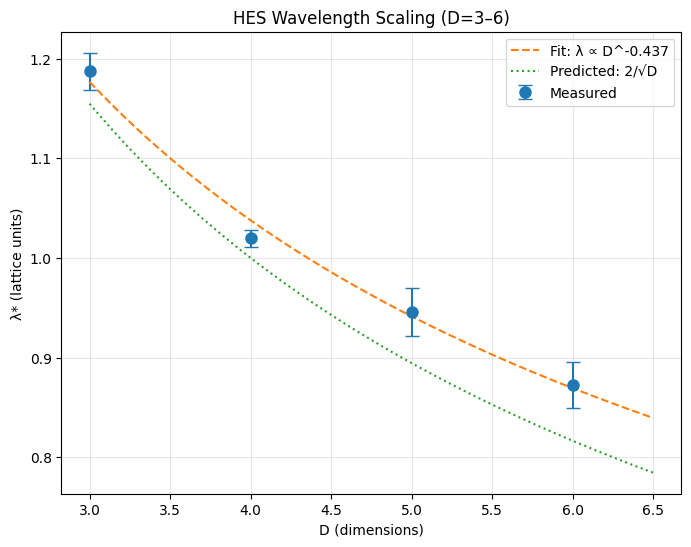

Fitted exponent: -0.4367 (pred -0.5000)


In [10]:
D_values = np.array(list(results.keys()))
lam_values = np.array([results[D]['mean'] for D in D_values])
lam_errors = np.array([results[D]['ci95'] for D in D_values])

log_D = np.log(D_values); log_lam = np.log(lam_values)
A = np.vstack([log_D, np.ones(len(log_D))]).T
m, c = np.linalg.lstsq(A, log_lam, rcond=None)[0]

D_fit = np.linspace(3, 6.5, 150)
lam_fit = np.exp(c) * D_fit**m

plt.figure(figsize=(8,6))
plt.errorbar(D_values, lam_values, yerr=lam_errors, fmt='o', capsize=5, markersize=8, label='Measured')
plt.plot(D_fit, lam_fit, '--', label=f'Fit: λ ∝ D^{m:.3f}')
plt.plot(D_fit, 2/np.sqrt(D_fit), ':', label='Predicted: 2/√D')
plt.xlabel('D (dimensions)'); plt.ylabel('λ* (lattice units)')
plt.title('HES Wavelength Scaling (D=3–6)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print(f"Fitted exponent: {m:.4f} (pred -0.5000)")


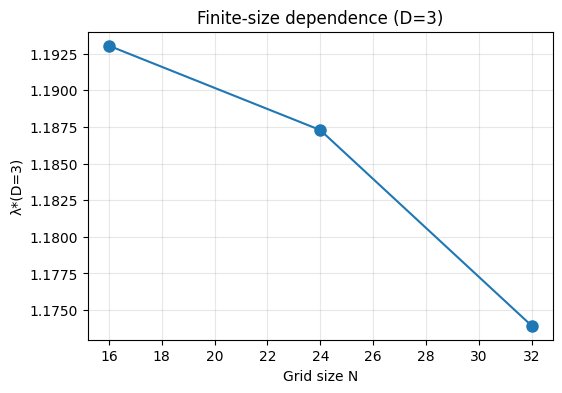

λ*(D=3) vs N: [(16, np.float64(1.1930470235194712)), (24, np.float64(1.1872878490494825)), (32, np.float64(1.1739282275910596))]


In [11]:
N_values = [16, 24, 32]
lam_vs_N = []
for N in N_values:
    lam_ensemble = []
    for seed in range(num_seeds):
        s = initialize_with_seeds(D=3, N=N, seed=seed)
        s = evolve_field(s, alpha=alpha, beta=beta, steps=steps)
        lam_ensemble.append(measure_lambda_with_DC_masking(s))
    lam_vs_N.append(np.mean(lam_ensemble))

plt.figure(figsize=(6,4))
plt.plot(N_values, lam_vs_N, 'o-', markersize=8)
plt.xlabel("Grid size N"); plt.ylabel("λ*(D=3)")
plt.title("Finite-size dependence (D=3)")
plt.grid(True, alpha=0.3); plt.show()

print("λ*(D=3) vs N:", list(zip(N_values, lam_vs_N)))
